In [ ]:
import sys
sys.path.insert(0, '..')  # examples/, where utils.py lives

from utils import fix_pythonpath_if_working_locally
fix_pythonpath_if_working_locally()

%load_ext autoreload
%autoreload 2

safetycage source: /Users/joelfinnbjervig/Documents/sintef/ongoing/safetycage-project/safetycage-pypi/src


## Load data
To guarantee no data leaks, we split the dataset into two, one to train the CNN, and the other to train the safetycage.
The `CIFAR10DataModule` makes the nessecary transforms and acts as a wrapper around the dataset such that function calls becomes standardised, and safetycage can call on it.

In [ ]:
import torch
from torchvision import datasets
import numpy as np
from sklearn.model_selection import train_test_split
from cifar10_datamodule import CIFAR10DataModule

# load the CIFAR-10 dataset
dataset = datasets.CIFAR10(root="./data", train=True, download=True)
y = np.array(dataset.targets) # Get the labels as a numpy array

# Split the dataset into model and cage datasets
x_model, x_cage, y_model, y_cage = train_test_split(
    dataset.data, y, test_size=0.5, random_state=42, stratify=y
)

# Split the model dataset into training, validation, and testing sets
x_model_train, x_model_temp, y_model_train, y_model_temp = train_test_split(x_model, y_model, test_size=0.2, random_state=42, stratify=y_model)
x_model_val, x_model_test, y_model_val, y_model_test = train_test_split(x_model_temp, y_model_temp, test_size=0.2, random_state=42, stratify=y_model_temp)


DEVICE = torch.device("mps")

# Create a CIFAR10DataModule instance for the model dataset
data_module_model = CIFAR10DataModule(
    x_train=x_model_train,
    y_train=y_model_train,
    x_val=x_model_val,
    y_val=y_model_val,
    x_test=x_model_test,
    y_test=y_model_test,
    device=DEVICE
    )
data_module_model.print_partition_summary()
data_module_model.plot_samples(n_samples_per_class=5)

## The model
For this example we use a convolutional neural network (CNN) to fit the input images of cifar-10 to their corresponing labels. We note that this model is not state of the art, but rather a model that exemplifies the usage of safetycage.

In [3]:
import os
import torch
from cnn import CNN

model = CNN()

CHECKPOINT = "./cnn_cifar10.pt"
if os.path.exists(CHECKPOINT):
    model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))

model.to(DEVICE)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (relu_fc1): ReLU()
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)

## Training the CNN
An untrained model will naturally make mistakes, so for this to become practically intressesting we need to train the model on the dedicated data partition.

In [4]:
from torch.utils.data import DataLoader, TensorDataset
from torch import nn

def as_loader(split, batch_size, shuffle=False, device="cpu"):
    """Wrap an (x, y) numpy split as a DataLoader."""
    x, y = split

    return DataLoader(
        TensorDataset(torch.from_numpy(x).float().to(device), torch.from_numpy(y).long().to(device)),
        batch_size=batch_size,
        shuffle=shuffle,
    )

epochs = 10
batch_size = 64
learning_rate = 1e-3


train_loader = as_loader(data_module_model.data_train, batch_size, shuffle=True, device=DEVICE)
val_loader = as_loader(data_module_model.data_val, batch_size, device=DEVICE)
test_loader = as_loader(data_module_model.data_test, batch_size, device=DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()


@torch.no_grad()
def evaluate(model, loader, device="mps"):
    """Return (mean loss, accuracy) over a loader."""
    model.eval()
    loss_fn = nn.CrossEntropyLoss()

    total_loss, correct, seen = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)

        total_loss += loss_fn(logits, y).item() * len(y)
        correct += (logits.argmax(dim=1) == y).sum().item()
        seen += len(y)

    return total_loss / seen, correct / seen


for epoch in range(1, epochs + 1):
    model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()

    val_loss, val_accuracy = evaluate(model, val_loader, device=DEVICE)
    print(f"epoch {epoch:2d}/{epochs}  val_loss {val_loss:.4f}  val_acc {val_accuracy:.4f}")


test_loss, test_accuracy = evaluate(model, test_loader, device=DEVICE)
print(f"test_loss {test_loss:.4f}  test_acc {test_accuracy:.4f}")

torch.save(model.state_dict(), CHECKPOINT)
print(f"saved {CHECKPOINT}")

epoch  1/10  val_loss 1.1371  val_acc 0.5816
epoch  2/10  val_loss 0.9755  val_acc 0.6480
epoch  3/10  val_loss 0.9414  val_acc 0.6672
epoch  4/10  val_loss 0.8747  val_acc 0.6980
epoch  5/10  val_loss 0.9181  val_acc 0.6934
epoch  6/10  val_loss 0.9507  val_acc 0.6936
epoch  7/10  val_loss 0.9379  val_acc 0.7055
epoch  8/10  val_loss 0.9382  val_acc 0.7137
epoch  9/10  val_loss 0.9724  val_acc 0.7091
epoch 10/10  val_loss 1.0913  val_acc 0.7105
test_loss 1.0588  test_acc 0.7075
saved ./cnn_cifar10.pt


## Model module
In addition, we wrap the CNNModelModule as well, 

In [7]:
from cnn_modelmodule import CNNModelModule
# from safetycage.modelmodules.torch_modelmodule import TorchModelModule
model_module = CNNModelModule(
    selected_layers='fc2',
    use_onehot_encoder=False,
    model=model,
    device=DEVICE
)

In [8]:
# Split the model dataset into training, validation, and testing sets
x_cage_train, x_cage_temp, y_cage_train, y_cage_temp = train_test_split(x_cage, y_cage, test_size=0.2, random_state=42)
x_cage_val, x_cage_test, y_cage_val, y_cage_test = train_test_split(x_cage_temp, y_cage_temp, test_size=0.2, random_state=42)

train x=(8000, 3, 32, 32) y=(8000,)
val   x=(1600, 3, 32, 32) y=(1600,)
test  x=(400, 3, 32, 32) y=(400,)


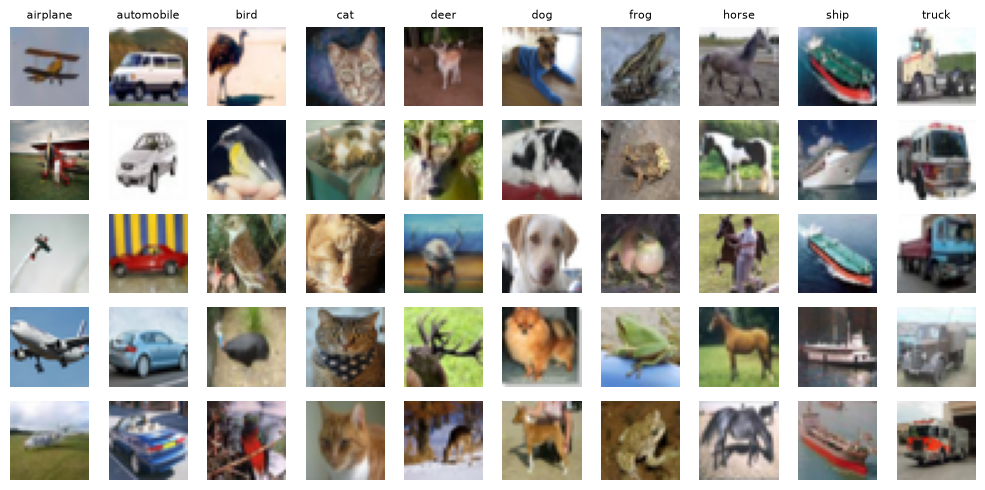

In [ ]:
from cifar10_datamodule import CIFAR10DataModule

data_module = CIFAR10DataModule(
    x_train=x_cage_train,
    y_train=y_cage_train,
    x_val=x_cage_val,
    y_val=y_cage_val,
    x_test=x_cage_test,
    y_test=y_cage_test,
    device=DEVICE
)

test samples       : 1600
accuracy           : 70.75%
misclassified      : 468


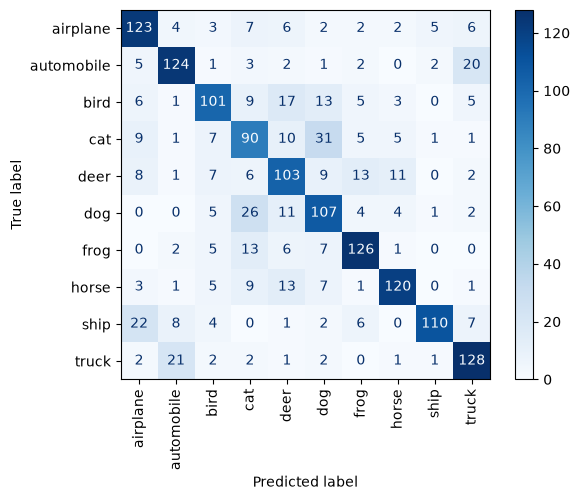

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

x_model_test, y_model_test = data_module_model.data_test
predictions_test = model_module._get_predictions(x_model_test)

incorrect_test = (predictions_test != y_model_test).astype(int)

print(f'test samples       : {len(x_model_test)}')
print(f'accuracy           : {(predictions_test == y_model_test).mean():.2%}')
print(f'misclassified      : {incorrect_test.sum()}')

cm = confusion_matrix(y_model_test, predictions_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data_module.classes.values())
cm_fig = disp.plot(cmap='Blues', xticks_rotation='vertical')

In [ ]:
from safetycage.methods.spardacus import SPARDACUS
from safetycage.methods.red import RED


# safetycage = SPARDACUS(model_module=model_module, data_module=data_module, s_statistic_source="correctly")
safetycage = RED(
    model_module=model_module, data_module=data_module,
    training_iterations = 100, batch_size=32)
# safetycage = DOCTOR(model_module=model_module, data_module=data_module,method= "max")
# safetycage = MSP(model_module=model_module, data_module=data_module)

# trains the cage with the train partition of the cage dataset partition
safetycage.train_cage()

x_val, y_val = data_module_model.data_val
predictions_val = model_module._get_predictions(x_val)
incorrect_val = (predictions_val != y_val).astype(int)
statistics_val = safetycage.predict(x_val, predictions_val)

Training RED: 100%|██████████| 100/100 [13:51<00:00,  8.32s/it, loss=0.496]


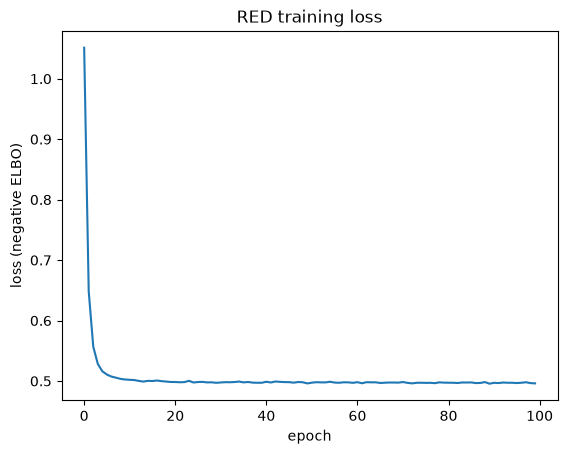

In [180]:
if hasattr(safetycage, "loss_history"):
    import matplotlib.pyplot as plt

    plt.plot(safetycage.loss_history)
    plt.xlabel("epoch")
    plt.ylabel("loss (negative ELBO)")
    plt.title(f"{type(safetycage).__name__} training loss")
    plt.show()

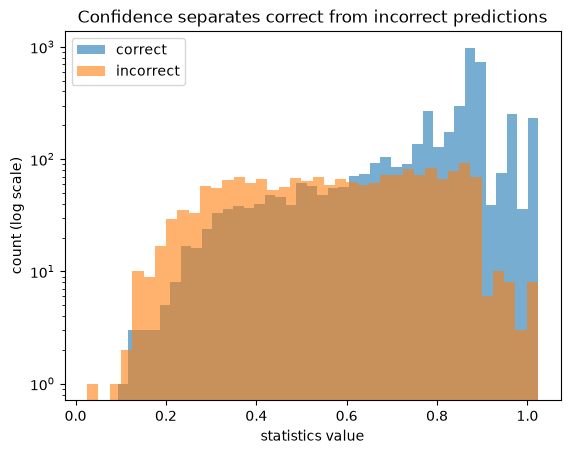

In [181]:
import matplotlib.pyplot as plt

plt.hist(statistics_val[incorrect_val == 0], bins=40, alpha=0.6, label='correct')
plt.hist(statistics_val[incorrect_val == 1], bins=40, alpha=0.6, label='incorrect')
plt.yscale('log')
plt.xlabel("statistics value")
plt.ylabel('count (log scale)')
plt.title('Confidence separates correct from incorrect predictions')
plt.legend()
plt.show()

In [182]:
from safetycage.utils.metrics import MCC
metric_fn = MCC

result_val = safetycage.find_best_threshold(
    y_true=incorrect_val,
    y_probs=statistics_val,
    metric_fn=metric_fn,
    search="log", 
)
threshold = result_val['threshold_opt']

print(f"optimal threshold : {result_val['threshold_opt']:.4f}")
print(f"{metric_fn.__name__} at threshold  : {float(result_val['metric_max']):.4f}")

optimal threshold : 0.7481
MCC at threshold  : 0.4300


In [183]:
x_test, y_test = data_module.data_test

y_pred_test = model_module._get_predictions(x_test)
statistics_test = safetycage.predict(x_test, y_pred_test)
incorrect_test = (y_pred_test != y_test).astype(int)
result_test = safetycage.find_best_threshold(
    y_true=incorrect_test,
    y_probs=statistics_test,
    metric_fn=metric_fn,
    search="log"
)

flagged_test = safetycage.flag(statistics_test, threshold)

caught = int((flagged_test & (incorrect_test == 1)).sum())
total_errors = int(incorrect_test.sum())

print(f'test samples           : {len(x_test)}')
print(f'actually misclassified : {total_errors}')
print(f'flagged by the cage    : {int(flagged_test.sum())}')
print(f'errors caught          : {caught} of {total_errors} ({caught / total_errors:.0%})')

test samples           : 400
actually misclassified : 115
flagged by the cage    : 160
errors caught          : 85 of 115 (74%)


In [184]:
x_train, y_train = data_module.data_train
y_pred_train = model_module._get_predictions(x_train)
statistics_train = safetycage.predict(x_train, y_pred_train)
incorrect_train = (y_pred_train != y_train).astype(int)

result_train = safetycage.find_best_threshold(
    y_true=incorrect_train,
    y_probs=statistics_train,
    metric_fn=metric_fn,
    search="log"
)

flagged_train = safetycage.flag(statistics_train, result_train['threshold_opt'])

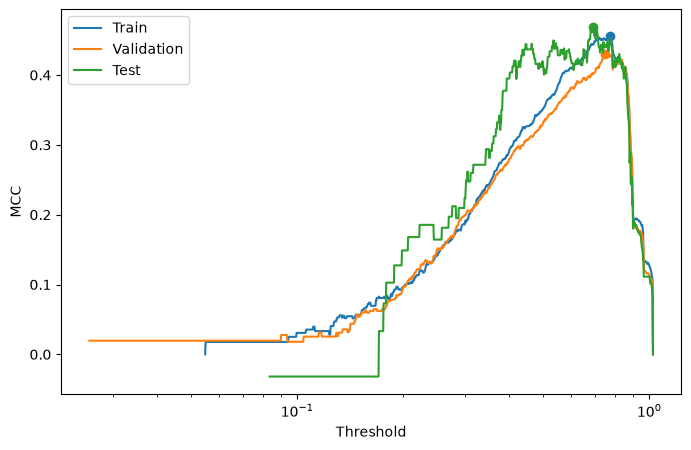

In [185]:
import matplotlib.pyplot as plt
from safetycage.utils.visualise import plot_metric_vs_threshold

fig, ax = plt.subplots(figsize=(8, 5))
plot_metric_vs_threshold(result_train['thresholds'], result_train['metrics'], ax=ax, label='Train')
plot_metric_vs_threshold(result_val['thresholds'], result_val['metrics'], ax=ax, label='Validation')
plot_metric_vs_threshold(result_test['thresholds'], result_test['metrics'], ax=ax, label='Test')
plt.xlabel('Threshold')
plt.ylabel(metric_fn.__name__)
plt.xscale('log')
ax.legend()
plt.show()

In [186]:
auroc = safetycage.auroc(y_true=incorrect_test, y_pred=statistics_test)
roc = safetycage.roc_curve(y_true=incorrect_test, y_pred=statistics_test)

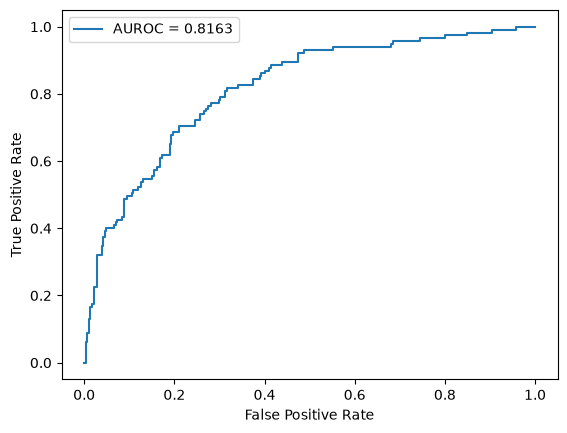

In [187]:
plt.plot(roc['fpr'], roc['tpr'], label=f'AUROC = {auroc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

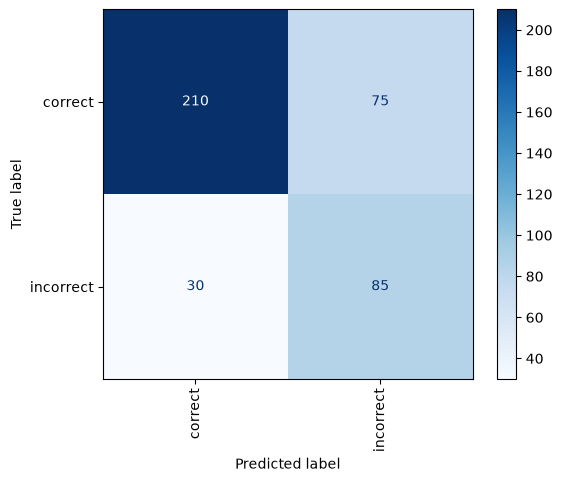

In [195]:
cm = confusion_matrix(y_true=incorrect_test, y_pred=flagged_test, normalize=None)
confusion_disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['correct', 'incorrect'])
confusion_disp.plot(cmap='Blues', xticks_rotation='vertical')


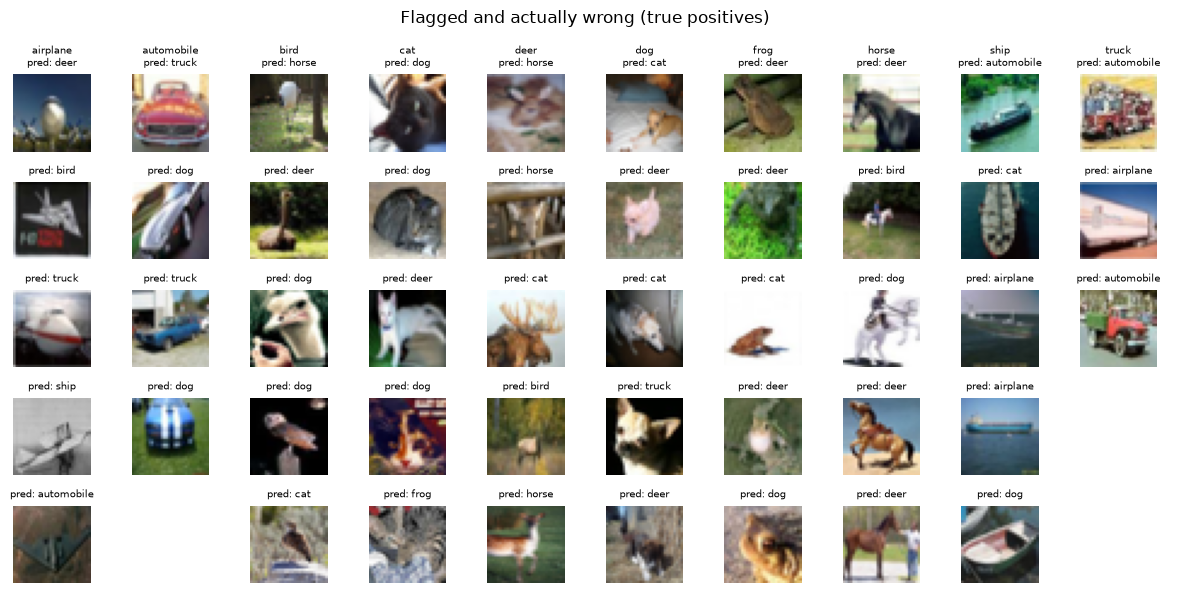

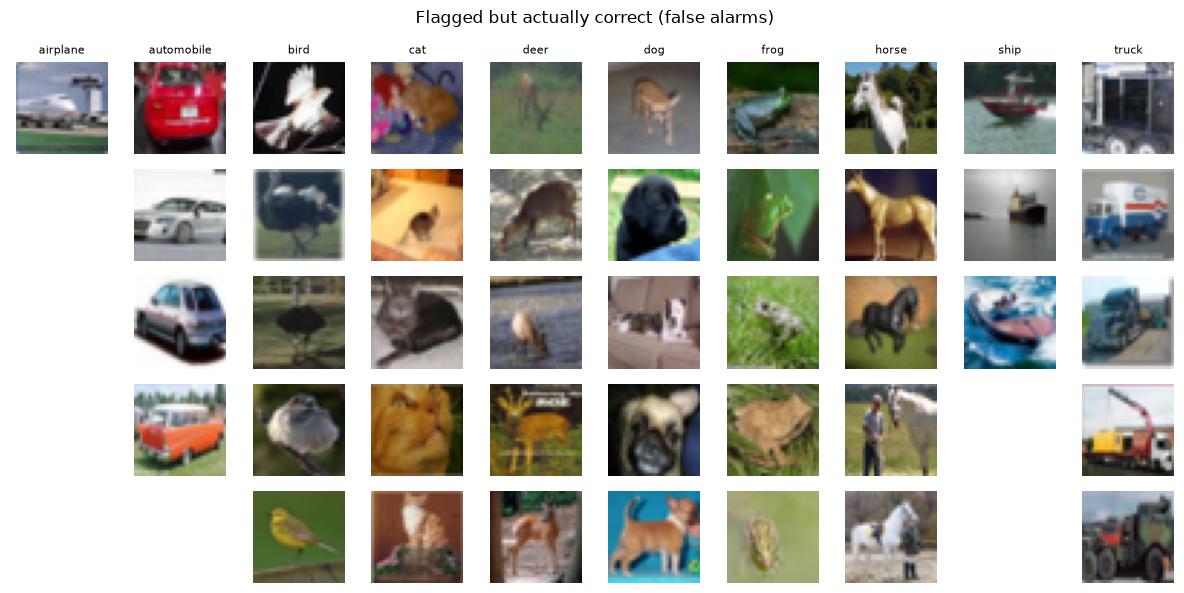

In [196]:
import numpy as np
import matplotlib.pyplot as plt
from cifar10_datamodule import CIFAR10_MEAN, CIFAR10_STD

N = 5  # rows per plot

def to_displayable(img):
    """Channel-first, possibly normalized float -> channel-last [0,1] for imshow."""
    if data_module.normalize:
        img = img * CIFAR10_STD.reshape(3, 1, 1) + CIFAR10_MEAN.reshape(3, 1, 1)
    return np.clip(img.transpose(1, 2, 0), 0, 1)


def plot_flagged_grid(mask, title, n_rows=N, show_prediction=False):
    fig, axes = plt.subplots(
        n_rows, data_module.num_classes,
        figsize=(data_module.num_classes * 1.2, n_rows * 1.2),
        squeeze=True,
    )

    for class_id, class_name in data_module.classes.items():
        class_idx = np.where((y_test == class_id) & mask)[0][:n_rows]

        for row in range(n_rows):
            ax = axes[row, class_id]
            if row < len(class_idx):
                idx = class_idx[row]
                ax.imshow(to_displayable(x_test[idx]))

                if show_prediction:
                    pred_label = data_module.classes[int(y_pred_test[idx])]
                    label = f"{class_name}\npred: {pred_label}" if row == 0 else f"pred: {pred_label}"
                    ax.set_title(label, fontsize=7)
                elif row == 0:
                    ax.set_title(class_name, fontsize=8)
            ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    
actually_wrong = flagged_test & (incorrect_test == 1)
false_alarms = flagged_test & (incorrect_test == 0)

plot_flagged_grid(actually_wrong, "Flagged and actually wrong (true positives)", show_prediction=True)
plot_flagged_grid(false_alarms, "Flagged but actually correct (false alarms)")

## Scenario 1: abstain on what the cage flags

The simplest way to use the cage: don't act on any prediction it flags at
all, and only trust the ones it lets through. That raises the reliability
of what you do act on, but costs coverage — fewer predictions you're
willing to use.

In [197]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

kept = ~flagged_test
missed_mask = kept & (incorrect_test == 1)
caught_mask = flagged_test & (incorrect_test == 1)

def classifier_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1 (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }

baseline_metrics = classifier_metrics(y_test, y_pred_test)
kept_metrics = classifier_metrics(y_test[kept], y_pred_test[kept])

print(f'{"metric":<20}{"baseline":>15}{"cage-kept":>15}{"change":>15}')
for name in baseline_metrics:
    print(f'{name:<20}{baseline_metrics[name]:>15.4f}{kept_metrics[name]:>15.4f}{kept_metrics[name] - baseline_metrics[name]:>+15.4f}')

print()
print(f'sent for review         : {int(flagged_test.sum())} of {len(x_test)}')
print(f'errors missed           : {int(missed_mask.sum())} of {total_errors}')
print(f'errors caught           : {int(caught_mask.sum())} of {total_errors}')
print(f'coverage                : {kept.mean():.2%} ({int(kept.sum())} of {len(x_test)})')

metric                     baseline      cage-kept         change
accuracy                     0.7125         0.8750        +0.1625
precision (macro)            0.7284         0.8637        +0.1353
recall (macro)               0.7151         0.8571        +0.1420
f1 (macro)                   0.7169         0.8571        +0.1401
MCC                          0.6810         0.8613        +0.1803

sent for review         : 160 of 400
errors missed           : 30 of 115
errors caught           : 85 of 115
coverage                : 60.00% (240 of 400)


## Scenario 2: review everything flagged, correct what's wrong

A different deployment: instead of abstaining, send every flagged sample
for review. A reviewer fixes the ones that really were misclassified and
leaves the false alarms as they were (already correct, just cost some
review time). Predictions the cage never flagged are left untouched —
including the errors it missed.

In [198]:
caught_mask = flagged_test & (incorrect_test == 1)
missed_mask = (~flagged_test) & (incorrect_test == 1)

corrected_test = y_pred_test.copy()
corrected_test[caught_mask] = y_test[caught_mask]

corrected_metrics = classifier_metrics(y_test, corrected_test)

print(f'{"metric":<20}{"baseline":>15}{"with review":>15}{"change":>15}')
for name in baseline_metrics:
    print(f'{name:<20}{baseline_metrics[name]:>15.4f}{corrected_metrics[name]:>15.4f}{corrected_metrics[name] - baseline_metrics[name]:>+15.4f}')

print()
print(f'sent for review         : {int(flagged_test.sum())} of {len(x_test)}')
print(f'errors missed           : {int(missed_mask.sum())} of {total_errors}')
print(f'errors caught           : {int(caught_mask.sum())} of {total_errors}')

metric                     baseline    with review         change
accuracy                     0.7125         0.9250        +0.2125
precision (macro)            0.7284         0.9256        +0.1972
recall (macro)               0.7151         0.9223        +0.2072
f1 (macro)                   0.7169         0.9226        +0.2056
MCC                          0.6810         0.9168        +0.2358

sent for review         : 160 of 400
errors missed           : 30 of 115
errors caught           : 85 of 115


## Recording results for cross-method comparison

Save everything computed above into `examples/results.json`, keyed by
(example, method). Every example notebook can contribute a row the same
way, so the file builds into a comparison table across every
misclassification-detection method you've run:
`pandas.DataFrame(json.loads(Path("examples/results.json").read_text()))`.

In [ ]:
from utils import save_result, flatten_metrics

method_name = type(safetycage).__name__

record = {
    "threshold": float(threshold),
    "auroc": float(auroc),
    "test_samples": int(len(x_test)),
    "total_errors": total_errors,
    "flagged": int(flagged_test.sum()),
    "errors_caught": int(caught_mask.sum()),
    "errors_missed": int(missed_mask.sum()),
    "coverage": float(kept.mean()),
    **flatten_metrics("baseline", baseline_metrics),
    **flatten_metrics("cage_kept", kept_metrics),
    **flatten_metrics("with_review", corrected_metrics),
}

path = save_result(example="03-cifar10-cnn", method=method_name, **record)

saved results for RED to /Users/joelfinnbjervig/Documents/sintef/ongoing/safetycage-project/safetycage-pypi/examples/results.json
